# Calculate the thermal relaxation timescale:

- number of particles per unit area in a column: 
$$ N = \int^{p1}_{p2} \frac{1}{g M_{mean}} = \frac{p1-p2}{g * M_{mean}} $$

- $c_m$ ($J/kg/K$): heat capacity per unit mass of species at a given temperature $T_{eff}$

- The total heat capacity per unit area is
$$ C = N c = \frac{(p_1 - p_2) c_m} {g}  $$

- The relaxation timescale is determined by timescale for all particles to radiate excess heat away. The linear Boltzmann law for small temperature changes is: 

$$ \tau = \frac{C}{dL/dT} = \frac{C}{4 \sigma T_{eff}^3 } = \frac{(p_1 - p_2) c_m}{4 \sigma T_{eff}^3 g} $$ 

### Using a simple Isothermal Profile 

In [1]:
import numpy as np
import astropy.constants as c
import astropy.units as u
import matplotlib.pyplot as plt

In [2]:
def tau_relaxation(g, Teff, delta_p, cm):
    return delta_p * cm / (g * 4 * c.sigma_sb * Teff **3 )

### Assuming an isothermal profile

# example L type brown dwarf
M = 30 * u.M_jup
R = 0.85 * u.R_jup

# gravity
g = c.G * M / R**2
Teff = 1200 * u.K

# cloud pressure level

# specific heat capacity for H2 at 1200K
cm = 15.3 * 1e3 * u.J / (u.kg * u.K)
print("gravity:", g.cgs)
print("heat capacity cm (H2 at 1200K):", cm)
print('effective temperature (assume isothermal profile): ', Teff)

for delta_p in [0.01, 0.1, 1, 10, 50]:

    t = tau_relaxation(g, Teff, delta_p * u.bar, cm)
    print("\n delta_p: ", delta_p * u.bar)
    print("relaxation time:", t.to(u.s), t.to(u.min))

gravity: 102919.80405321445 cm / s2
heat capacity cm (H2 at 1200K): 15300.0 J / (K kg)
effective temperature (assume isothermal profile):  1200.0 K

 delta_p:  0.01 bar
relaxation time: 37.92949094283882 s 0.6321581823806469 min

 delta_p:  0.1 bar
relaxation time: 379.2949094283882 s 6.321581823806469 min

 delta_p:  1.0 bar
relaxation time: 3792.949094283882 s 63.21581823806469 min

 delta_p:  10.0 bar
relaxation time: 37929.49094283882 s 632.1581823806468 min

 delta_p:  50.0 bar
relaxation time: 189647.45471419411 s 3160.7909119032347 min


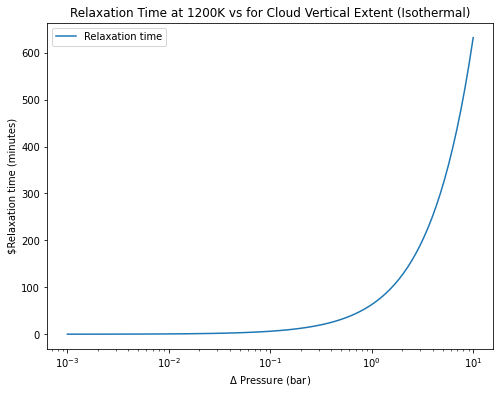

In [4]:
# plot the relaxation time
plt.figure(figsize=(8, 6))
p_grid = np.logspace(-3, 1, 100) * u.bar
t_grid = tau_relaxation(g, Teff, p_grid, cm)
plt.plot(p_grid.to(u.bar), t_grid.to(u.min), label='Relaxation time')
plt.xscale('log')
plt.yscale('linear')
plt.xlabel(r'$\Delta$ Pressure (bar)')
plt.ylabel('$Relaxation time (minutes)')
plt.title('Relaxation Time at 1200K vs for Cloud Vertical Extent (Isothermal)')
plt.legend()

Text(0, 0.5, 'Relaxation time for $\\Delta P = $ 0.2 bar(minutes) (Isothermal)')

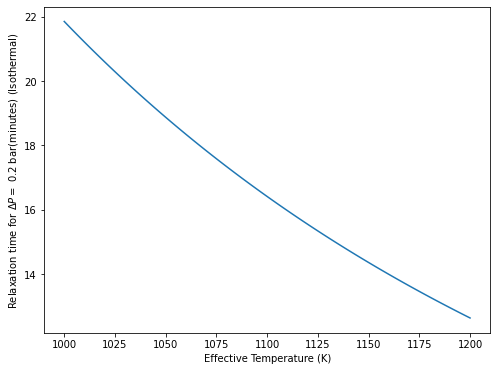

In [5]:
# plot the relaxation time
plt.figure(figsize=(8, 6))
teff_grid = np.linspace(1000, 1200, 100) * u.K
t_grid = tau_relaxation(g, teff_grid, 0.2 *  u.bar, cm)
plt.plot(teff_grid.to(u.K), t_grid.to(u.min), label='Relaxation time')
plt.xscale('linear')
plt.yscale('linear')
plt.xlabel('Effective Temperature (K)')
plt.ylabel(r'Relaxation time for $\Delta P = $ 0.2 bar(minutes) (Isothermal)') 

### Using PT profile from Sonora Bobcat

In [1]:
# Set environment variables for PICASO reference data    
picaso_refdata = "/Users/nguyendat/Documents/GitHub/picaso/reference/"
pysyn_cdbs = "/Users/nguyendat/Documents/GitHub/picaso/reference/stellar_spectra/grp/redcat/trds"
picaso_home = '/Users/nguyendat/Documents/GitHub/picaso/'

import os 
"""Set environment variables for PICASO reference data."""
os.environ['picaso_refdata'] = picaso_refdata
os.environ['PYSYN_CDBS'] = pysyn_cdbs

from picaso import justdoit as jdi
from virga import justdoit as vjdi

import importlib
importlib.reload(vjdi)

#plot tools
from picaso import justplotit as jpi
from virga import justplotit as vjpi

import astropy.units as u
import pandas as pd
from bokeh.plotting import show, figure
from bokeh.io import output_notebook 
output_notebook()

import pickle as pickle
import numpy as np

Loading BokehJS ...

====== Configured a brown dwarf atmosphere with: ======
Teff: 1200 K, log(g): 4.0, C/O: 0.55, [M/H]: 1.0, kzz: 10000000.0 cm^2/s


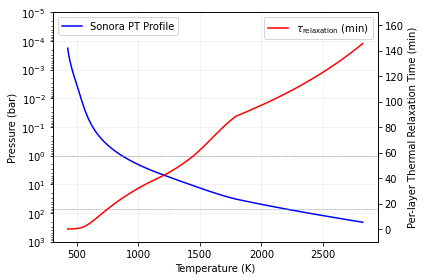

In [52]:
#point to where you untared your sonora profiles
sonora_profile_db = '/Users/nguyendat/Documents/GitHub/picaso/data/sonora_profile/'

def configure_atm(C_to_O=0.55, mh=1.0, Teff=1200,
                  gravity=10000, kzz=1e7, phase=0, wave_range=[1,6], 
                  eq = False, excluded_mol = 'CH4'):
    """
    This function configures a brown dwarf atmosphere with the following inputs:
    C_to_O: float, carbon to oxygen ratio
    mh: float, metallicity in [M/H], default: 1.0, solar.  VIRGA BROWN DWARF WILL GIVE ERROR FOR MH.
    Teff: int, effective temperature in Kelvin
    gravity: float, surface gravity in m/s^2
    kzz: float, vertical mixing coefficient in cm^2/s
    phase: float, phase angle in radians
    wave_range: list, wavelength range in microns [min, max]
    eq: bool, whether to use chemical equilibrium (True) or disequilibrium (False)
    """
    
    opa = jdi.opannection(wave_range=wave_range) # define opacity range
    bd = jdi.inputs(calculation='browndwarf') # define brown dwarf model/ use no star
    bd.phase_angle(phase) #radians #phase angle of 0 is full phase
    bd.gravity(gravity=gravity, gravity_unit=u.Unit('m/(s**2)')) #any astropy units available

    #this function will grab the gravity you have input above and find the nearest neighbor with the 
    #note sonora chemistry grid is on the same opacity grid as our opacities (1060). 
    bd.sonora(sonora_profile_db, Teff) # get sonora profile closest to Teff and input gravity

    if eq: # if using chemical equilibrium
        bd.chemeq_visscher(C_to_O, mh) # compute chemeq with visscher grid

    # Add kzz (vertical mixing) to the profile
    profile = bd.inputs['atmosphere']['profile'] 
    profile['kzz'] = np.ones(profile['pressure'].shape[0])*[kzz]
    profile['kz'] = profile['kzz'].copy() # virga wants it named 'kz' so add it again

    bd.atmosphere(df=profile, exclude_mol=excluded_mol) # input the profile with disequilibrium chemistry

    print('====== Configured a brown dwarf atmosphere with: ======')
    print(f'Teff: {Teff} K, log(g): {np.log10(gravity)}, C/O: {C_to_O}, [M/H]: {mh}, kzz: {kzz} cm^2/s')

    return bd, opa, profile

# let's try to make a normal atmosphere
bd, opa, profile = configure_atm(C_to_O=0.55)

fig=figure(y_axis_type="log",x_axis_type='log', y_range=(1e3, 1e-6))

# Example: plot the Sonora PT profile with pressure on y-axis
p = profile['pressure']
T = profile['temperature']

# Calculate the relaxation time for the Sonora Profile at each temperature
t_sonora = []
t_sonora_cumulative = []
for i, T_element in enumerate(T):
    # Take delta p as the pressure difference between adjacent layers
    if i == 0:
        delta_p = - p[i] + p[i+1]
    else:
        delta_p = - p[i-1] + p[i]
        
    t_relax = tau_relaxation(g, T_element * u.K, delta_p * u.bar, cm)
    t_sonora.append(t_relax.to(u.minute).value)

# plot the PT profile with T on x-axis and P on left y-axis with relaxation time on right y-axis
save = True
# save = False

fig, ax = plt.subplots(figsize=(6,4))

ax2 = ax.twinx()
ax.plot(T, p, label='Sonora PT Profile', color='blue')
ax2.plot(T, t_sonora, label=r'$\tau_\mathrm{relaxation}$ (min)', color='red')
# ax2.plot(T, t_sonora_cumulative, label=r'Cumulative $\tau_\mathrm{relaxation}$ (min)', color='orange', linestyle='--')
ax.set_xscale('linear')
ax.set_yscale('log')
ax.set_xlabel(f'Temperature (K)')
ax.set_ylabel(f'Pressure (bar)')
ax2.set_ylabel('Per-layer Thermal Relaxation Time (min)')
# ax.set_title('Sonora PT Profile and Relaxation Time')
ax.invert_yaxis()
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

# plot lines around p=1 bar and p=80 bar as parameter region
ax.axhline(y=1, color='gray', linestyle='--', label='1 bar', lw=0.5)
ax.axhline(y=70, color='gray', linestyle='--', label='80 bar', lw=0.5)
ax.grid(True, alpha=0.3, lw=0.5)
ax.set_ylim(1e3, 1e-5)
ax2.set_ylim(-10, 170)

plt.tight_layout()

plotDir = '/Users/nguyendat/Documents/GitHub/polarVortexJwst/paperPlots/'
if save:
    plt.savefig(plotDir + 'sonora_PT_profile_relaxation_time.pdf', dpi=300)
plt.show()
